# 📌 Extracción

En esta sección se realizará la extracción de los datos desde el archivo JSON proporcionado para el análisis de churn de clientes de TelecomX.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

## Cargar JSON

In [2]:
with open('TelecomX_Data.json') as f:
    data = json.load(f)

#Convertir a DataFrame

In [36]:
df = pd.json_normalize(data)

#Inspección Inicial

In [37]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [15]:
df.shape

(7032, 21)

In [16]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   float64
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 
 17  

# 🔧 Transformación

En esta etapa se realizará la limpieza y preparación de los datos para facilitar el análisis posterior. Esto incluye la normalización de nombres de columnas, conversión de tipos de datos y tratamiento de valores faltantes.

## Renombrar columnas

In [38]:
df.columns = df.columns.str.replace("customer.", "", regex=False)
df.columns = df.columns.str.replace("phone.", "", regex=False)
df.columns = df.columns.str.replace("internet.", "", regex=False)
df.columns = df.columns.str.replace("account.", "", regex=False)

In [39]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

#Transformar churn

In [40]:
df["Churn"].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869
,224


In [41]:
df["Churn"] = df["Churn"].replace({
    "Yes": 1,
    "No": 0
})

In [42]:
df["Churn"].value_counts(dropna=False)

,count
Churn,
0,5174
1,1869
,224


#Convertir cargos totales

In [43]:
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")

#Revisar nulos

In [24]:
df.isnull().sum()

,0
customerID,0
Churn,7032
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


#Eliminar nulos

In [44]:
df = df.dropna(subset=["Charges.Total"])

In [45]:
df.shape

(7256, 21)

# 📊 Carga y análisis

En esta sección se realiza el análisis exploratorio de los datos con el objetivo de identificar patrones relacionados con la evasión de clientes (churn).

#Tasa general de churn

In [47]:
df["Churn"].unique()

array([0, 1, ''], dtype=object)

In [48]:
df["Churn"] = df["Churn"].replace('', np.nan)

/tmp/ipykernel_956/2702039165.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace('', np.nan)


In [49]:
df["Churn"] = pd.to_numeric(df["Churn"])

In [50]:
df["Churn"].unique()

array([ 0.,  1., nan])

In [51]:
churn_rate = df["Churn"].mean() * 100
print(f"Tasa de churn: {churn_rate:.2f}%")

Tasa de churn: 26.58%


# 📊 Carga y análisis

En esta sección se realiza el análisis exploratorio de los datos con el objetivo de identificar patrones relacionados con la evasión de clientes (churn). Se calcularán métricas descriptivas y se generarán visualizaciones para entender mejor el comportamiento de los clientes y los factores asociados a su cancelación del servicio.

In [52]:
#Tasa_general_de_Churn
churn_rate = df["Churn"].mean() * 100
print(f"Tasa de churn: {churn_rate:.2f}%")

Tasa de churn: 26.58%


#Distribución de Churn

In [53]:
df["Churn"].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [54]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


#Gráfico de Churn

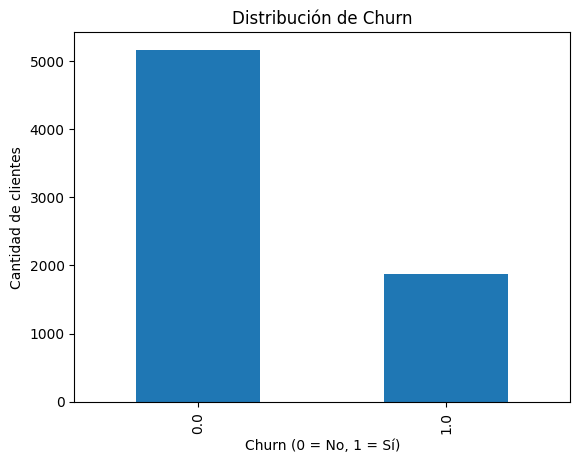

In [55]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de clientes")

plt.show()

#Churn por contrato

In [56]:
contract_churn = df.groupby("Contract")["Churn"].mean() * 100
contract_churn

,Churn
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665


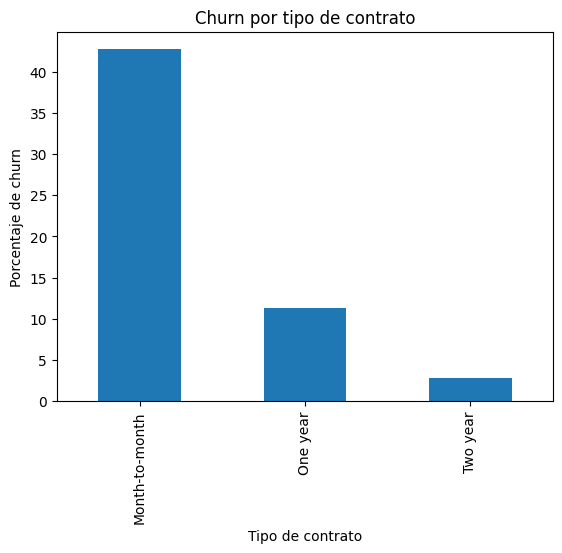

In [57]:
contract_churn.plot(kind="bar")

plt.title("Churn por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Porcentaje de churn")

plt.show()

#Churn por método de pago

In [58]:
payment_churn = df.groupby("PaymentMethod")["Churn"].mean() * 100
payment_churn

,Churn
PaymentMethod,
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123
Electronic check,45.285412
Mailed check,19.201995


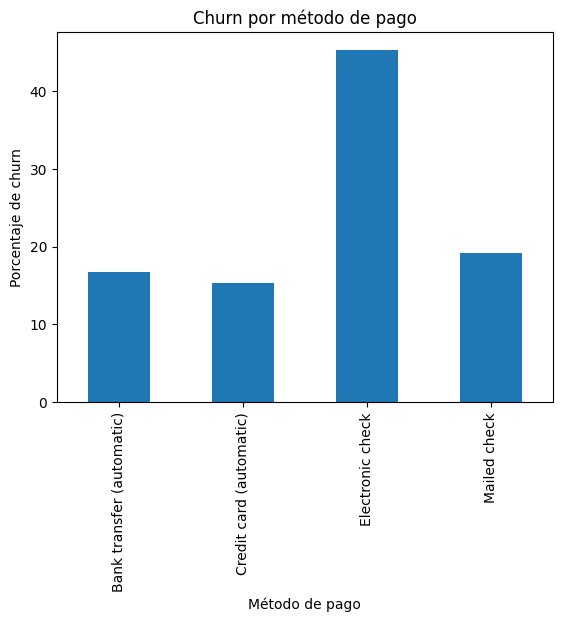

In [59]:
payment_churn.plot(kind="bar")

plt.title("Churn por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Porcentaje de churn")

plt.show()

#Distribución de permanencia

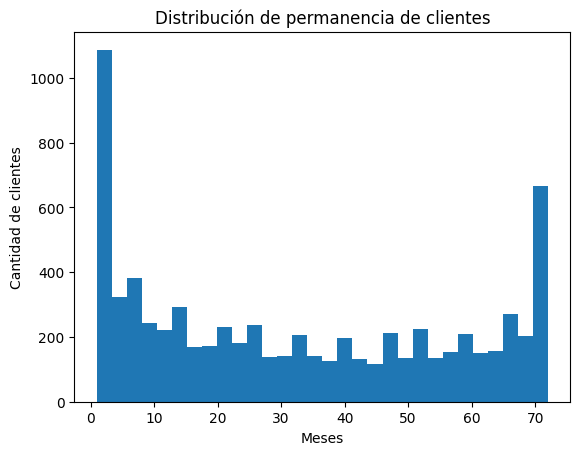

In [60]:
plt.hist(df["tenure"], bins=30)

plt.title("Distribución de permanencia de clientes")
plt.xlabel("Meses")
plt.ylabel("Cantidad de clientes")

plt.show()

#Relación entre permanencia y cargos

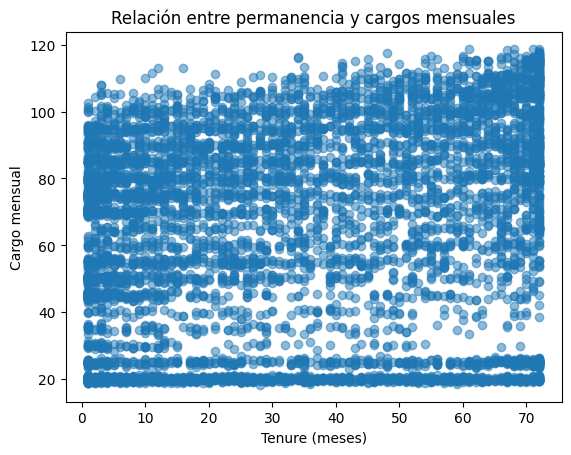

In [61]:
plt.scatter(df["tenure"], df["Charges.Monthly"], alpha=0.5)

plt.title("Relación entre permanencia y cargos mensuales")
plt.xlabel("Tenure (meses)")
plt.ylabel("Cargo mensual")

plt.show()

#Churn por servicio de Internet

In [62]:
internet_churn = df.groupby("InternetService")["Churn"].mean() * 100
internet_churn

,Churn
InternetService,
DSL,18.998344
Fiber optic,41.892765
No,7.434211


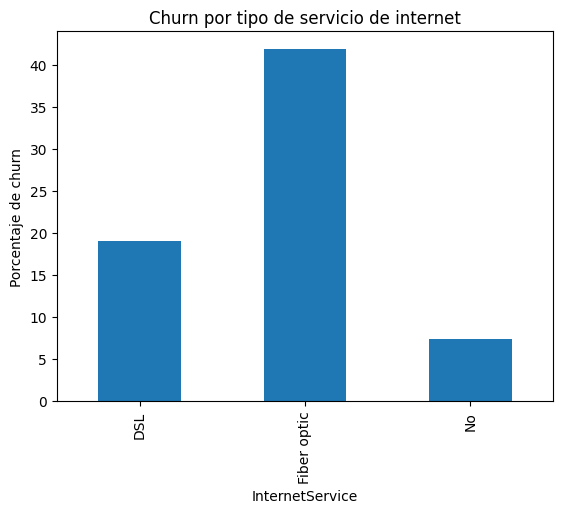

In [63]:
internet_churn.plot(kind="bar")

plt.title("Churn por tipo de servicio de internet")
plt.ylabel("Porcentaje de churn")

plt.show()

# 📄 Informe final

En este análisis se exploró el comportamiento de los clientes de TelecomX con el objetivo de identificar posibles factores asociados a la evasión de clientes (churn).

## Tasa general de churn

La tasa general de churn calculada fue aproximadamente **26.58%**, lo que indica que cerca de una cuarta parte de los clientes han cancelado el servicio.

## Principales hallazgos

### Tipo de contrato
Se observó que los clientes con contratos **Month-to-month** presentan una tasa significativamente mayor de churn en comparación con aquellos que tienen contratos de **uno o dos años**. Esto sugiere que los contratos de largo plazo contribuyen a una mayor retención de clientes.

### Método de pago
Al analizar los métodos de pago, algunos presentan mayores tasas de churn que otros. Esto podría indicar que ciertos métodos de pago están asociados con menor fidelización o con perfiles de clientes más propensos a cancelar el servicio.

### Permanencia del cliente (tenure)
Los clientes con menor tiempo de permanencia tienden a abandonar el servicio con mayor frecuencia. Esto sugiere que el período inicial de la relación con el cliente es crítico para su retención.

### Servicios contratados
El tipo de servicio de internet también muestra diferencias en las tasas de churn, lo que podría estar relacionado con la calidad percibida del servicio o las expectativas de los clientes.

## Recomendaciones

A partir de los resultados obtenidos, se sugieren las siguientes acciones:

- Incentivar contratos de mayor duración mediante promociones o descuentos.
- Implementar estrategias de retención enfocadas en clientes nuevos.
- Analizar los métodos de pago asociados con mayor churn para entender posibles fricciones en el proceso de pago.
- Fortalecer la oferta de servicios adicionales que aumenten el valor percibido por el cliente.

## Conclusión

El análisis exploratorio permitió identificar variables relevantes relacionadas con la evasión de clientes. Estos hallazgos pueden servir como base para que el equipo de ciencia de datos desarrolle modelos predictivos que permitan anticipar la cancelación de clientes y diseñar estrategias efectivas de retención.